# Unit 2: EEG预处理基础操作

## 理论知识

### 2.1 预处理的重要性

EEG信号极其微弱（10-100 μV），容易受到多种噪声和伪迹的干扰。预处理的目的是：
- **提高信噪比（SNR）**：去除与脑电无关的信号成分
- **保证数据质量**：识别和处理坏通道、坏时段
- **标准化数据**：使不同受试者、不同实验的数据具有可比性

### 2.2 滤波（Filtering）

**高通滤波（High-pass Filter）**：
- 去除低频漂移和直流偏移
- 常用截止频率：0.1-1 Hz
- 注意事项：过高的高通滤波会扭曲ERP成分

**低通滤波（Low-pass Filter）**：
- 去除高频噪声（如肌肉活动、线路噪声）
- 常用截止频率：30-40 Hz（ERP分析），或保留更高频率（时频分析）

**陷波滤波（Notch Filter）**：
- 专门去除电源线干扰（50 Hz或60 Hz）
- 窄带滤波，仅影响特定频率附近

**滤波器类型**：
- FIR（有限脉冲响应）：线性相位，无相位失真，但计算量大
- IIR（无限脉冲响应）：计算效率高，但可能引入相位失真

### 2.3 重参考（Re-referencing）

EEG测量的是两点之间的电位差。参考电极的选择会影响数据解释：

**常见参考方式：**
- **平均参考（Average Reference）**：所有电极的平均值作为参考
  - 优点：假设所有电极平均电位为零
  - 要求：需要高密度电极覆盖（建议≥32通道）
  
- **乳突参考（Mastoid Reference）**：使用乳突电极作为参考
  - 优点：远离大脑活动区域
  
- **Cz参考**：使用头顶中央电极作为参考
  - 常用于数据采集时的在线参考

### 2.4 坏道检测与插值

**坏道类型：**
- 高阻抗导致的低信噪比
- 电极脱落或接触不良
- 持续的高频或低频噪声

**检测方法：**
- 基于方差：坏道通常具有异常高或低的方差
- 基于相关性：坏道与其他通道的相关性较低
- 基于频谱：异常频谱特征

**插值方法：**
- 球面样条插值（Spherical Spline Interpolation）
- 使用周围正常通道的空间信息重建坏道数据

### 2.5 ICA去伪迹（独立成分分析）

**ICA原理：**
- 假设观测信号是多个独立源信号的线性混合
- 目标是分离出统计独立的成分
- 公式：X = A·S，其中X是观测信号，S是独立源，A是混合矩阵

**常见伪迹成分：**
- **眼电（EOG）**：眨眼、眼动，表现为前额区域的大幅度偏转
- **心电（ECG）**：心跳伪迹，时间锁定到心跳周期
- **肌肉活动（EMG）**：高频、局部化分布

**ICA应用步骤：**
1. 对数据进行高通滤波（建议≥1 Hz）
2. 运行ICA算法分解数据
3. 识别伪迹成分（手动或自动）
4. 排除伪迹成分，重建数据

### 2.6 Epoch提取与基线校正

**Epoch提取：**
- 根据事件标记（trigger）将连续数据切分为固定时间窗口
- 通常包含事件前的基线期（如-200 ms）和事件后的分析期（如500-1000 ms）

**基线校正：**
- 目的：消除trial间的直流偏移差异
- 方法：减去基线期的平均值
- 常用基线窗口：事件前100-200 ms

### 2.7 伪迹拒绝（Artifact Rejection）

**自动拒绝标准：**
- 幅度阈值：排除超过特定幅度（如±100 μV）的epochs
- 梯度阈值：排除幅度过快变化的epochs
- 方差阈值：排除方差异常的epochs

**autoreject库：**
- 自动学习每个通道的最优拒绝阈值
- 支持坏道插值和epoch拒绝两种策略

## 实践代码

In [1]:
# 导入必要的库
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne.preprocessing import ICA, create_eog_epochs, create_ecg_epochs

# 设置MNE日志级别
mne.set_log_level('WARNING')

print("Unit 2: EEG预处理基础操作")
print("=" * 40)

Unit 2: EEG预处理基础操作


### 1. 加载数据

In [183]:
# 修改MNE配置，指向本地数据集目录
data_dir = os.path.abspath("../datasets")
os.makedirs(data_dir, exist_ok=True)
mne.set_config("MNE_DATA", data_dir)
mne.set_config("MNE_DATASETS_SAMPLE_PATH", data_dir)

# 加载示例数据, 低通滤波后的数据0-40Hz
sample_data_folder = mne.datasets.sample.data_path()
raw_file = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw.fif'
raw = mne.io.read_raw_fif(raw_file, preload=True)

# 查看数据信息
print(f"数据加载完成: {len(raw.ch_names)} 个通道")
print(f"采样率: {raw.info['sfreq']} Hz")
print(f"持续时间: {raw.times[-1]:.2f} 秒")


数据加载完成: 376 个通道
采样率: 150.15374755859375 Hz
持续时间: 277.71 秒


### 2. 滤波处理 - 对所有通道进行滤波-除了stim通道

#### 2.1 高通滤波

高通滤波完成 (0.1 Hz)


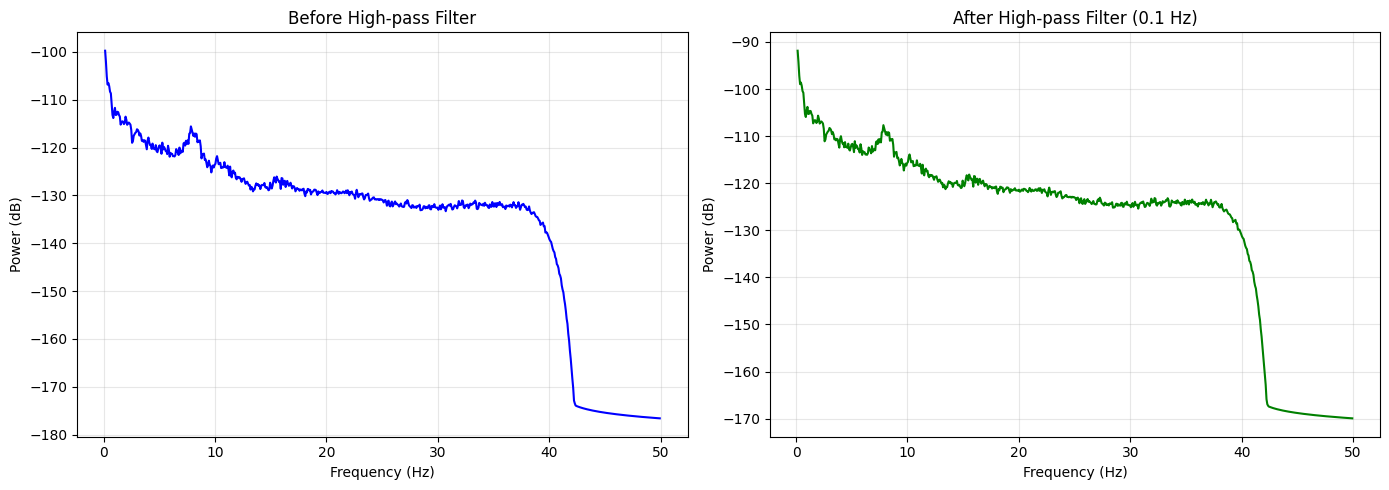

对比滤波前后的功率谱可视化完成


In [ ]:
# 创建数据副本以避免修改原始数据
raw_filtered = raw.copy().pick(['eeg','eog'])

# 应用高通滤波 (0.1 Hz)
# l_trans_bandwidth: 低频过渡带宽，默认为'auto'
# filter_length: 滤波器长度，'auto'表示根据数据自动选择
raw_filtered.filter(
    l_freq=0.1,           # 低频截止频率，高通滤波器保留高于此频率的成分
    h_freq=None,          # 高频截止频率，None表示不应用低通滤波
    fir_design='firwin',  # FIR滤波器设计方法，'firwin'使用窗口法设计
    verbose=False         # 不显示详细的处理信息
)
print("高通滤波完成 (0.1 Hz)")


# 对比滤波前后的功率谱
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 滤波前,计算功率谱密度
spectrum = raw.compute_psd(
    method='welch',  # 使用Welch方法进行PSD估计
    fmin=0.1,        # 最小频率0.5 Hz
    fmax=50,         # 最大频率50 Hz
    n_fft=2048       # FFT点数2048
)
psd_raw = spectrum.get_data(return_freqs=False) # shape:(59, 680)
freqs_raw = spectrum.freqs
axes[0].plot(freqs_raw, 10 * np.log10(psd_raw.mean(axis=0)), color='blue')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power (dB)')
axes[0].set_title('Before High-pass Filter')
axes[0].grid(True, alpha=0.3)

# 滤波后,计算功率谱密度
spectrum = raw_filtered.compute_psd(
    method='welch',  # 使用Welch方法进行PSD估计
    fmin=0.1,        # 最小频率0.5 Hz
    fmax=50,         # 最大频率50 Hz
    n_fft=2048       # FFT点数2048
)
psd_filt = spectrum.get_data(return_freqs=False) # shape:(59, 680)
freqs_filt = spectrum.freqs # shape:(59)
axes[1].plot(freqs_filt, 10 * np.log10(psd_filt.mean(axis=0)), color='green')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Power (dB)')
axes[1].set_title('After High-pass Filter (0.1 Hz)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("对比滤波前后的功率谱可视化完成")

#### 2.2 低通滤波

低通滤波完成 (40 Hz)


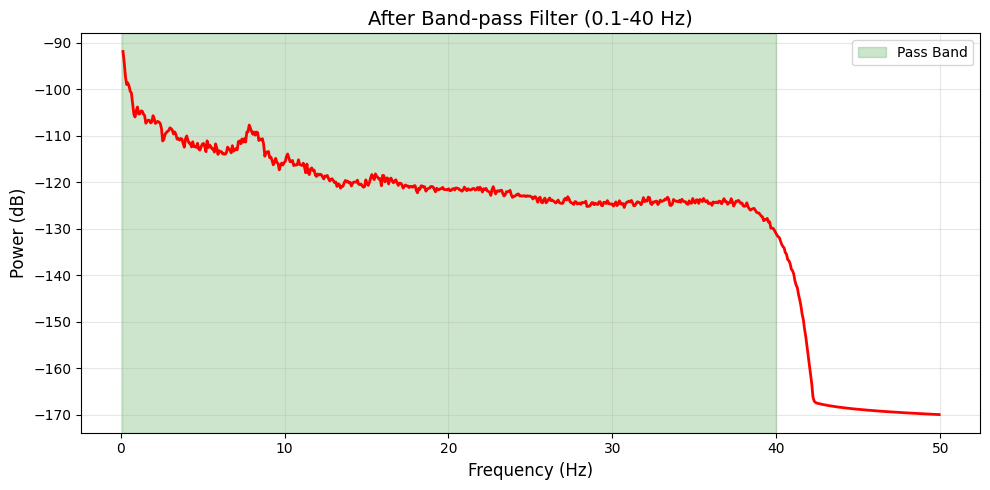

带通滤波效果可视化完成


In [185]:
# 应用低通滤波 (40 Hz)
# 适用于ERP分析，去除高频噪声
raw_filtered.filter(
    l_freq=None, 
    h_freq=40, 
    fir_design='firwin', 
    verbose=False
)
print("低通滤波完成 (40 Hz)")

# 可视化带通滤波效果
fig, ax = plt.subplots(figsize=(10, 5))

spectrum = raw_filtered.compute_psd(
    method='welch',  # 使用Welch方法进行PSD估计
    fmin=0.1,        # 最小频率0.5 Hz
    fmax=50,         # 最大频率50 Hz
    n_fft=2048       # FFT点数2048
)
psd_final = spectrum.get_data(return_freqs=False) # shape:(59, 680)
freqs_final = spectrum.freqs # shape:(59)
ax.plot(freqs_final, 10 * np.log10(psd_final.mean(axis=0)), color='red', linewidth=2)
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (dB)', fontsize=12)
ax.set_title('After Band-pass Filter (0.1-40 Hz)', fontsize=14)
ax.axvspan(0.1, 40, alpha=0.2, color='green', label='Pass Band')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("带通滤波效果可视化完成")

#### 2.3 陷波滤波（去除电源线干扰）

In [33]:
# 检查是否需要陷波滤波
# 欧洲使用50 Hz，美国使用60 Hz
# 示例数据已经滤波，这里演示如何应用陷波滤波
raw_notch = raw.copy()

# 对50 Hz及其谐波（100 Hz, 150 Hz）应用陷波滤波
freqs_to_notch = [50, 100, 150]
raw_notch.notch_filter(freqs=freqs_to_notch, 
                       method='spectrum_fit',
                       filter_length='auto',
                       verbose=False)
print(f"陷波滤波完成，去除频率: {freqs_to_notch} Hz")

陷波滤波完成，去除频率: [50, 100, 150] Hz


### 3. 重参考（Re-referencing）- 只对EEG\EOG通道进行
数据集中已经有平均参考投影器，不需要再应用平均参考。

In [186]:
# 应用平均参考
raw_reref = raw_filtered.copy()

# 激活投影前
print(raw_reref.info['projs'][0])
print(raw_reref.info['custom_ref_applied'])

# 激活平均参考投影器
raw_reref.apply_proj() # 应用投影器，数据会被修改

# 激活投影后
print(raw_reref.info['projs'][0])
print(raw_reref.info['custom_ref_applied'])

print("平均参考投影器激活完成")

# 应用平均参考重参考
# raw_reref.set_eeg_reference(ref_channels='average', projection=False)
# print(raw_reref.info['custom_ref_applied'])
print("平均参考重参考设置完成")

<Projection | Average EEG reference, active : False, n_channels : 60>
0 (FIFFV_MNE_CUSTOM_REF_OFF)
<Projection | Average EEG reference, active : True, n_channels : 60>
0 (FIFFV_MNE_CUSTOM_REF_OFF)
平均参考投影器激活完成
平均参考重参考设置完成


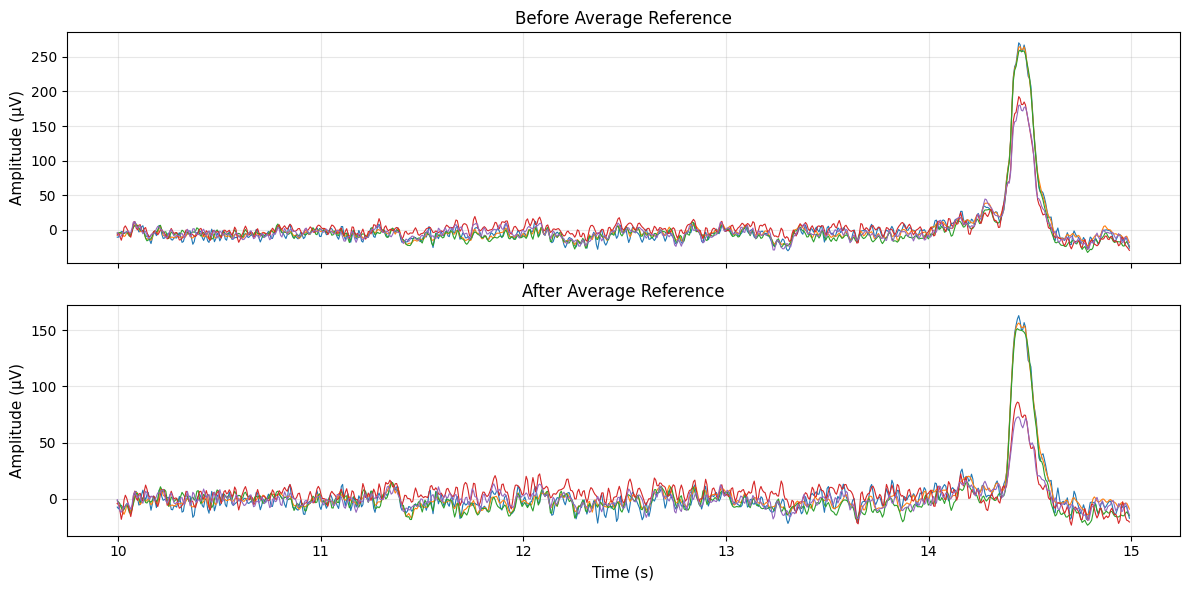

In [196]:

# 可视化参考变更对数据的影响
# 绘制参考前后的对比（选取单个通道）
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# raw[start:stop, start:stop] 是 MNE 特有的二维切片：
start = int(10*raw_filtered.info['sfreq'])
stop = int(15*raw_filtered.info['sfreq'])
times = raw_filtered.times[start:stop]

# 参考前（原参考）
# raw[通道选择, 时间范围]
# 返回元组(data, times)
data_before = raw_filtered.get_data(picks='eeg')[:5, start:stop]
# .T 把形状从 (5, 752) 转置为 (752, 5) ，使每列是一个通道的时间序列
axes[0].plot(times, data_before.T * 1e6, linewidth=0.8)  # 转换为μV
axes[0].set_ylabel('Amplitude (μV)', fontsize=11)
axes[0].set_title('Before Average Reference', fontsize=12)
axes[0].grid(True, alpha=0.3)

# 参考后（平均参考）
data_after = raw_reref.get_data(picks='eeg')[:5, start:stop]
axes[1].plot(times, data_after.T * 1e6, linewidth=0.8)
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('Amplitude (μV)', fontsize=11)
axes[1].set_title('After Average Reference', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 4. 坏道检测与插值

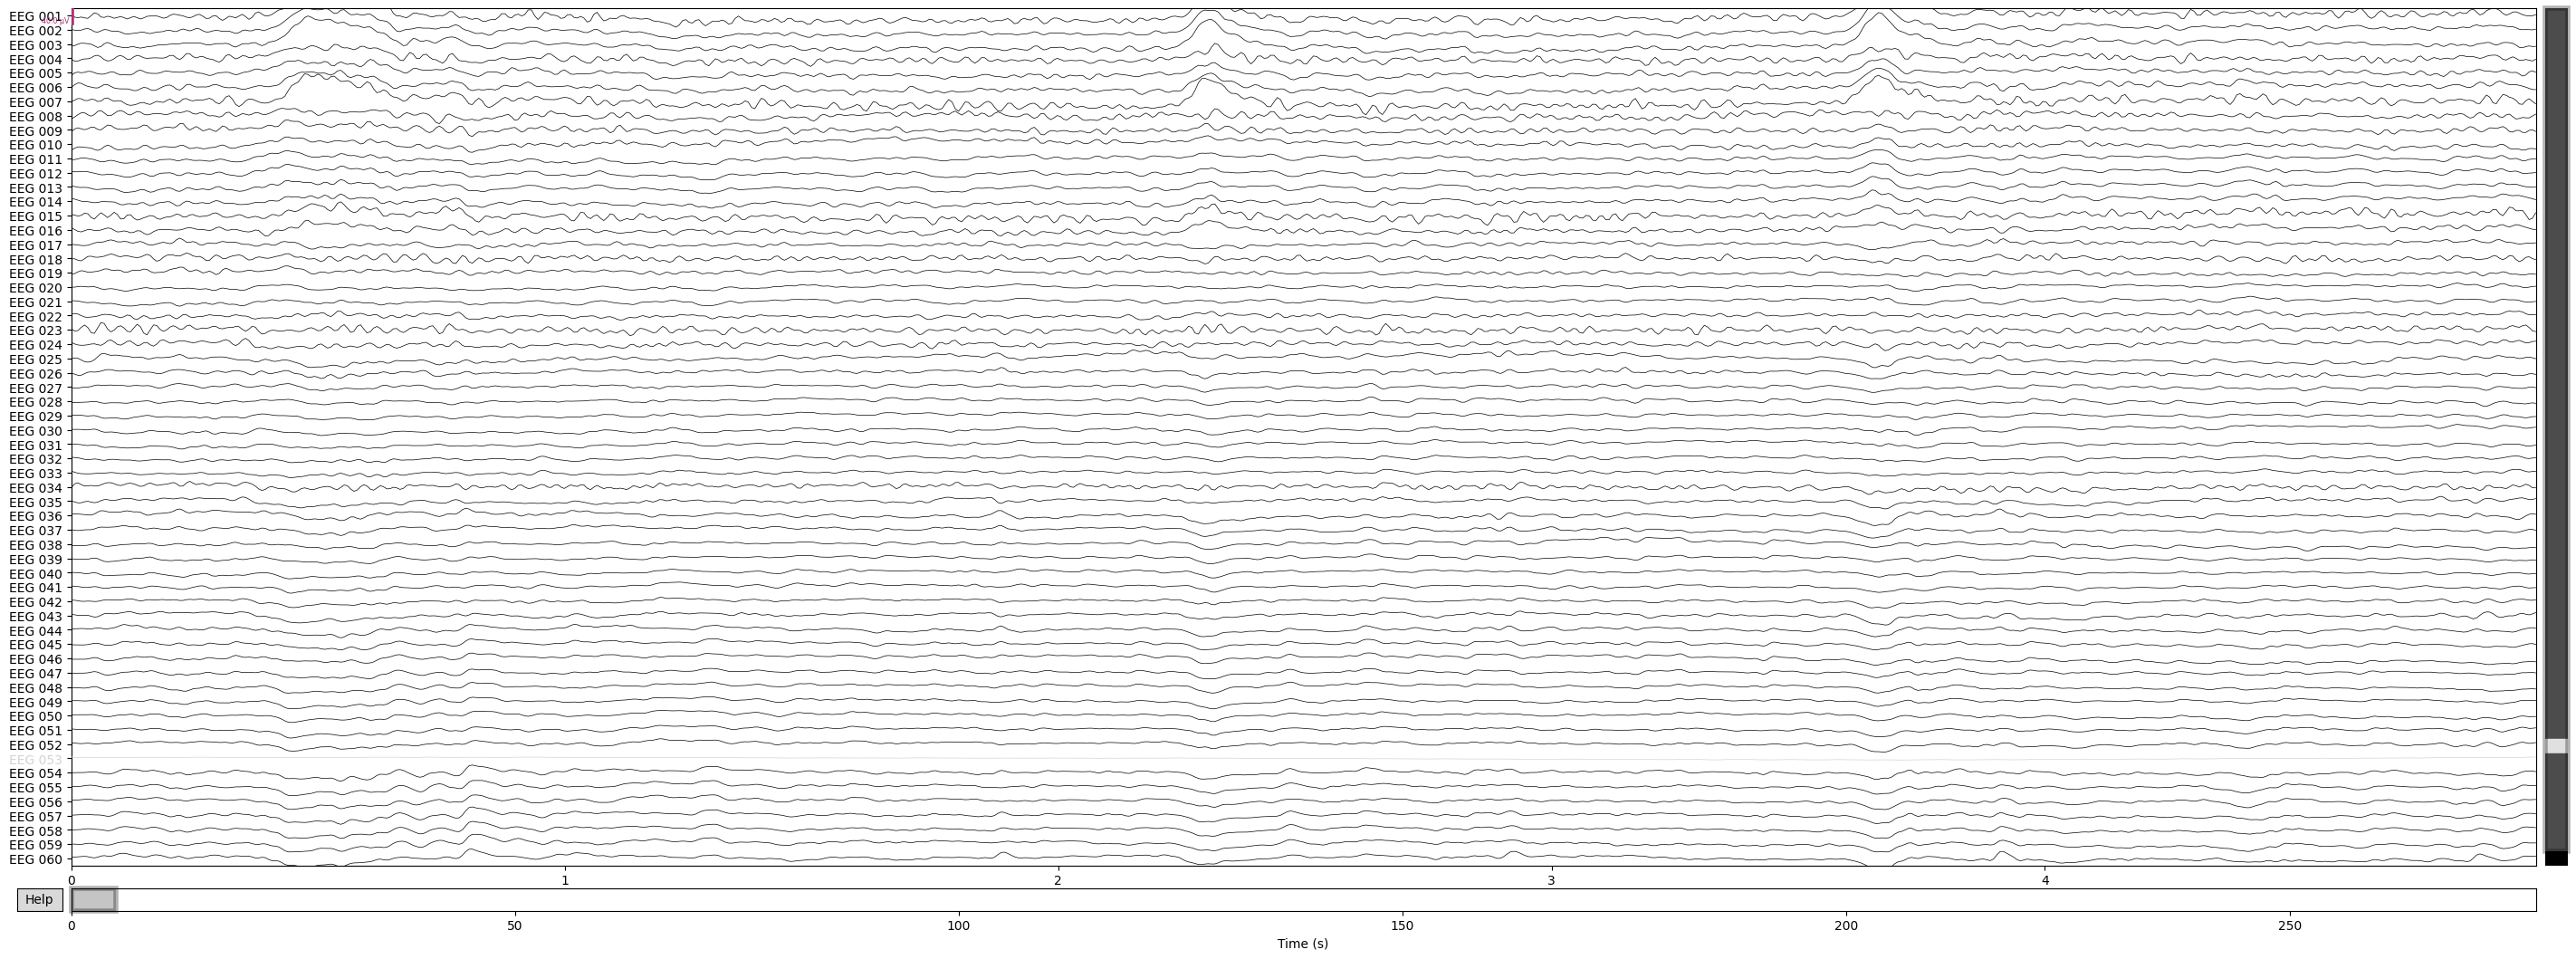

提示: 在弹出的窗口中点击通道名称可标记为坏道（背景变红）
关闭窗口后，坏道信息将保存在 raw.info['bads'] 中

当前坏道列表: ['EEG 053']


In [197]:
# 使用MNE内置的坏道检测方法
# 方法1: 基于通道间的相关性和方差的坏道检测


# 方法2: 可视化检测（手动标注）
raw_reref.plot(duration=5, n_channels=60, title='Bad Channel Detection (Visual)',
               show_scrollbars=True, block=False)
print("提示: 在弹出的窗口中点击通道名称可标记为坏道（背景变红）")
print("关闭窗口后，坏道信息将保存在 raw.info['bads'] 中")

# 查看当前标注的坏道
print(f"\n当前坏道列表: {raw_reref.info['bads']}")

In [198]:
if len(raw_reref.info['bads']) > 0:
    print(f"检测到 {len(raw_reref.info['bads'])} 个坏道: {raw_reref.info['bads']}")
    
    # 插值坏道
    # 使用球面样条插值方法
    raw_interp = raw_reref.copy()
    raw_interp.interpolate_bads(reset_bads=True, verbose=False)
    print(f"坏道插值完成，插值后坏道列表: {raw_interp.info['bads']}")
else:
    print("未检测到坏道，跳过插值步骤")
    print("\n模拟插值演示:")
    # 为演示目的，人工标记一个通道为坏道
    raw_demo = raw_reref.copy()
    raw_demo.info['bads'] = ['EEG 001']  # 假设EEG 001是坏道
    print(f"标记坏道: {raw_demo.info['bads']}")
    raw_demo.interpolate_bads(reset_bads=True, verbose=False)
    print("插值完成")

检测到 1 个坏道: ['EEG 053']
坏道插值完成，插值后坏道列表: []


再次检查

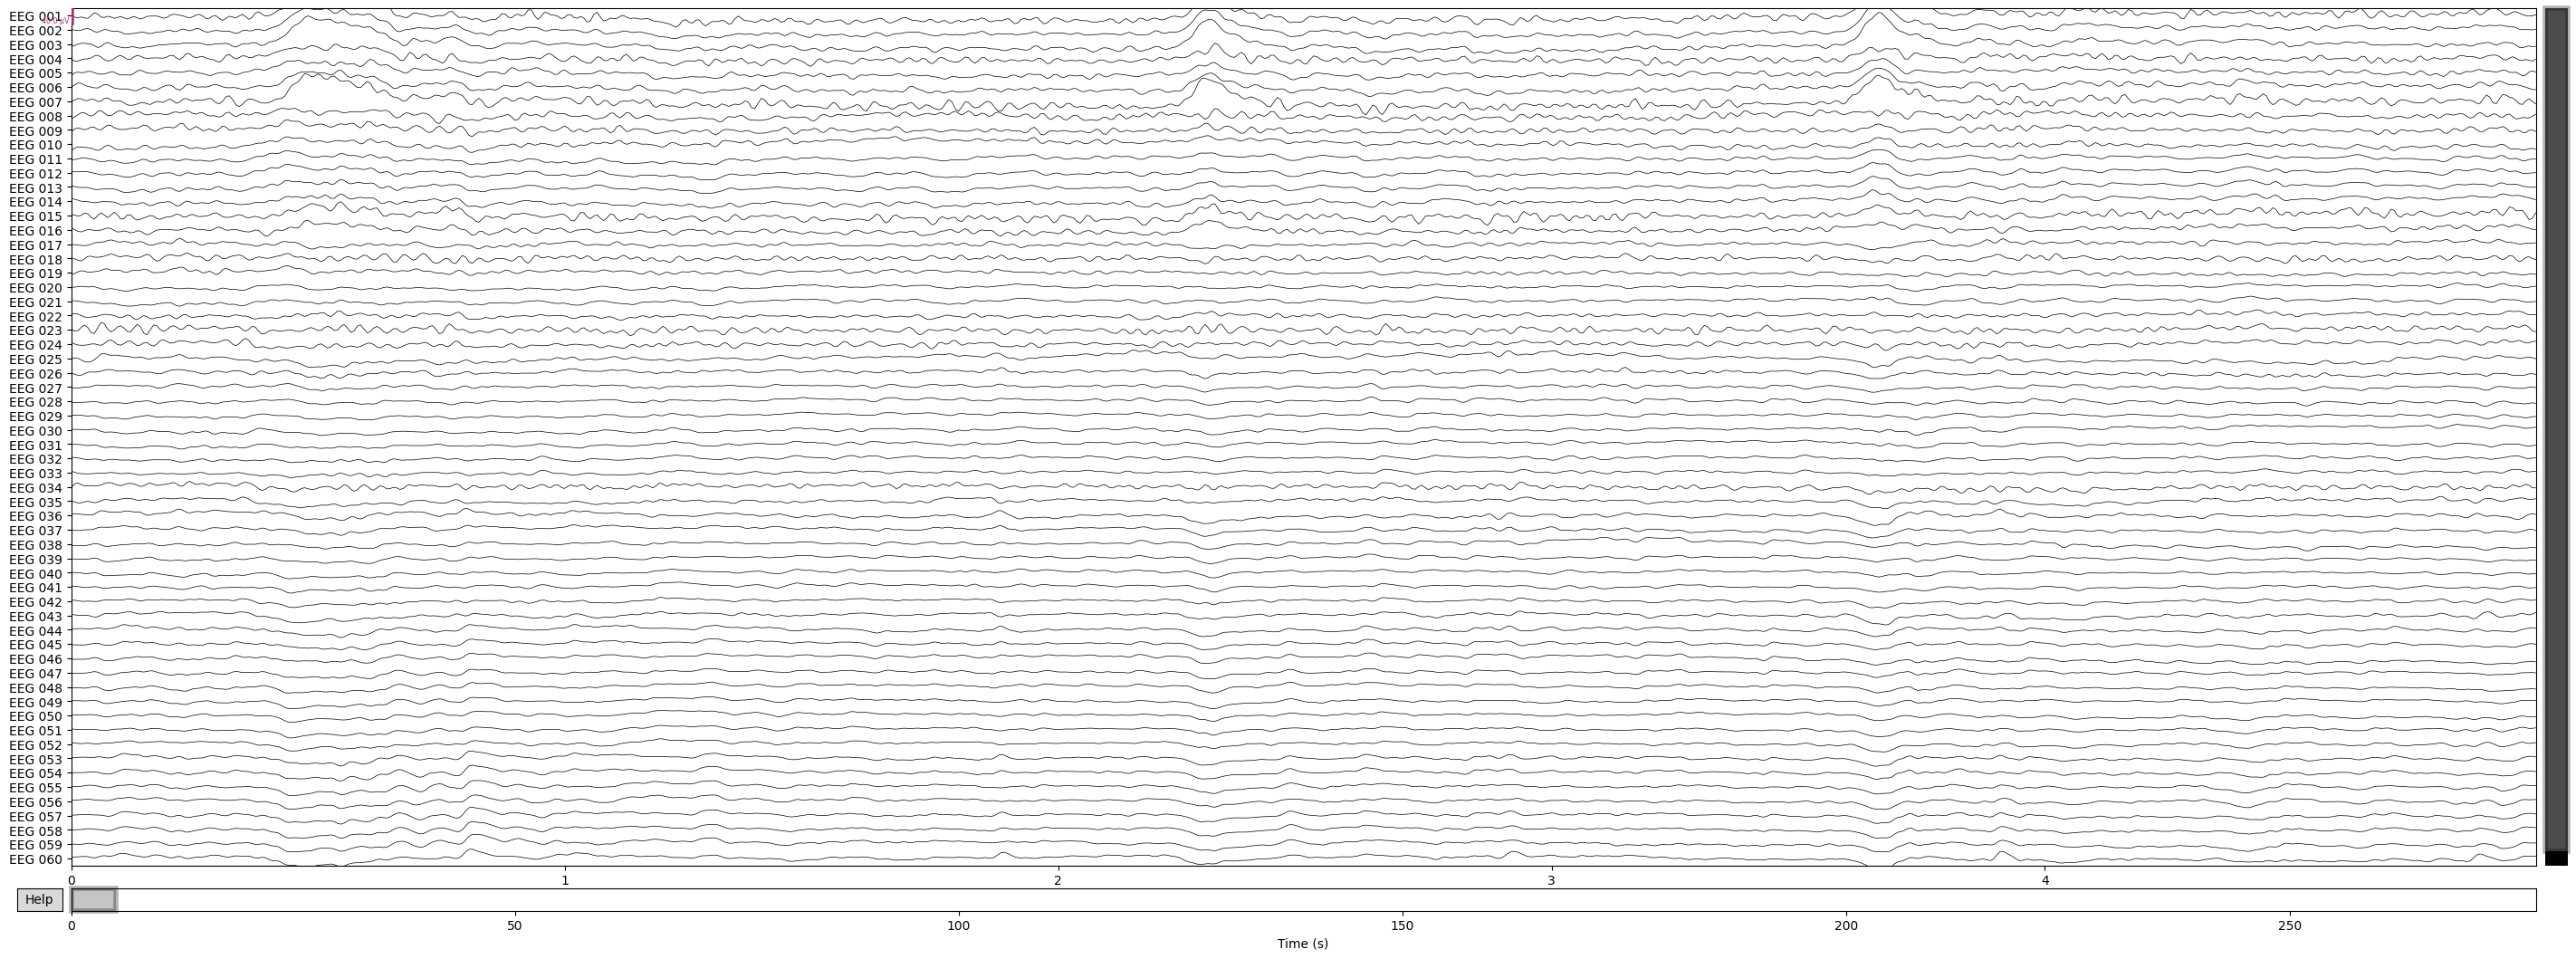

提示: 在弹出的窗口中点击通道名称可标记为坏道（背景变红）
关闭窗口后，坏道信息将保存在 raw.info['bads'] 中

当前坏道列表: []


In [199]:
# 使用MNE内置的坏道检测方法
# 方法1: 基于通道间的相关性和方差的坏道检测


# 方法2: 可视化检测（手动标注）
raw_interp.plot(duration=5, n_channels=60, title='Bad Channel Detection (Visual)',
               show_scrollbars=True, block=False)
print("提示: 在弹出的窗口中点击通道名称可标记为坏道（背景变红）")
print("关闭窗口后，坏道信息将保存在 raw.info['bads'] 中")

# 查看当前标注的坏道
print(f"\n当前坏道列表: {raw_interp.info['bads']}")

### 5. ICA去伪迹

#### 5.1 运行ICA

In [206]:
# ICA需要高通滤波后的数据（建议≥1 Hz）
# 创建适合ICA的数据副本
raw_ica: mne.io.RawArray = raw_interp.copy().pick(['eeg','eog'])
raw_ica.filter(l_freq=1.0, h_freq=None, verbose=False)
print("为ICA应用1 Hz高通滤波")

# 配置ICA参数
# n_components: 要提取的独立成分数量
#   - 可以是整数（绝对数量）或浮点数（保留的方差比例）
# method: ICA算法类型
#   - 'fastica': FastICA算法（默认）
#   - 'picard': Picard算法（更快）
# max_iter: 最大迭代次数
ica = ICA(n_components=0.95,  # 保留95%的方差
          method='fastica',
          max_iter='auto',
          random_state=42)  # 设置随机种子以确保可重复性

# 拟合ICA模型
print("正在拟合ICA模型...")
ica.fit(
    raw_ica,
    picks='eeg', # 仅处理EEG通道
    verbose=False
)
print(f"ICA拟合完成，提取了 {ica.n_components_} 个成分")

# 查看ICA解释的方差
explained_var = ica.pca_explained_variance_
cumulative_var = np.cumsum(explained_var) / np.sum(explained_var) * 100
print(f"\n前5个PCA成分的累积解释方差:")
for i in range(min(5, len(cumulative_var))):
    print(f"  成分 {i+1}: {cumulative_var[i]:.1f}%")

为ICA应用1 Hz高通滤波
正在拟合ICA模型...
ICA拟合完成，提取了 19 个成分

前5个PCA成分的累积解释方差:
  成分 1: 49.6%
  成分 2: 59.9%
  成分 3: 69.3%
  成分 4: 76.5%
  成分 5: 79.8%


#### 5.2 识别EOG相关成分

检测到的EOG相关成分索引: [np.int64(0)]


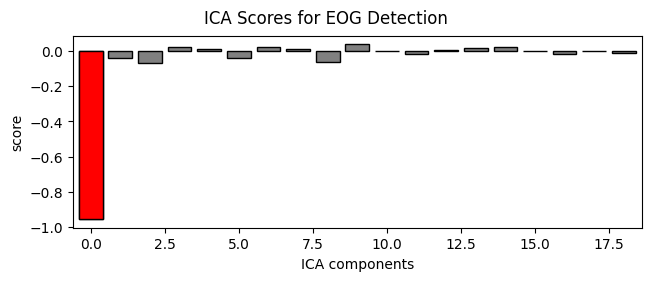

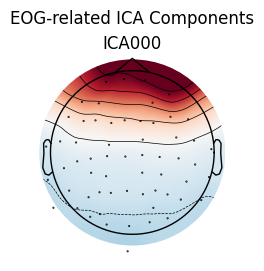

ICA处理完成


In [207]:
# 使用EOG通道自动识别眼电相关成分
# 原理: 计算每个ICA成分与EOG通道的相关性

# 如果数据中有EOG通道，创建EOG epochs
eog_indices, eog_scores = ica.find_bads_eog(raw_ica, ch_name='EOG 061', verbose=False)
print(f"检测到的EOG相关成分索引: {eog_indices}")

# 绘制EOG成分的分数和topography
if len(eog_indices) > 0:
    ica.plot_scores(eog_scores, exclude=eog_indices, 
                    title='ICA Scores for EOG Detection')
    ica.plot_components(eog_indices, title='EOG-related ICA Components')
else:
    print("未检测到明显的EOG相关成分")
    print("这可能是因为数据质量较好或EOG信号较弱")
print("ICA处理完成")

#### 5.3 识别ECG相关成分

In [208]:
# 识别心电相关成分
# 需要ECG通道，或使用ECG事件的代理方法
ecg_indices = []
ecg_scores = []
try:
    ecg_indices, ecg_scores = ica.find_bads_ecg(raw_ica, method='ctps', verbose=False)
    print(f"检测到的ECG相关成分索引: {ecg_indices}")
    
    if len(ecg_indices) > 0:
        ica.plot_scores(ecg_scores, exclude=ecg_indices, 
                    title='ICA Scores for ECG Detection')
        ica.plot_components(ecg_indices, title='ECG-related ICA Components')
except Exception as e:
    print(f"ECG检测未找到明显成分: {e}")
    ecg_indices = []
print("ICA处理完成")

ECG检测未找到明显成分: Generating an artificial ECG channel can only be done for MEG data.
ICA处理完成


#### 5.4 排除伪迹成分并重建数据

将排除的成分索引: [np.int64(0)]

ICA伪迹去除完成


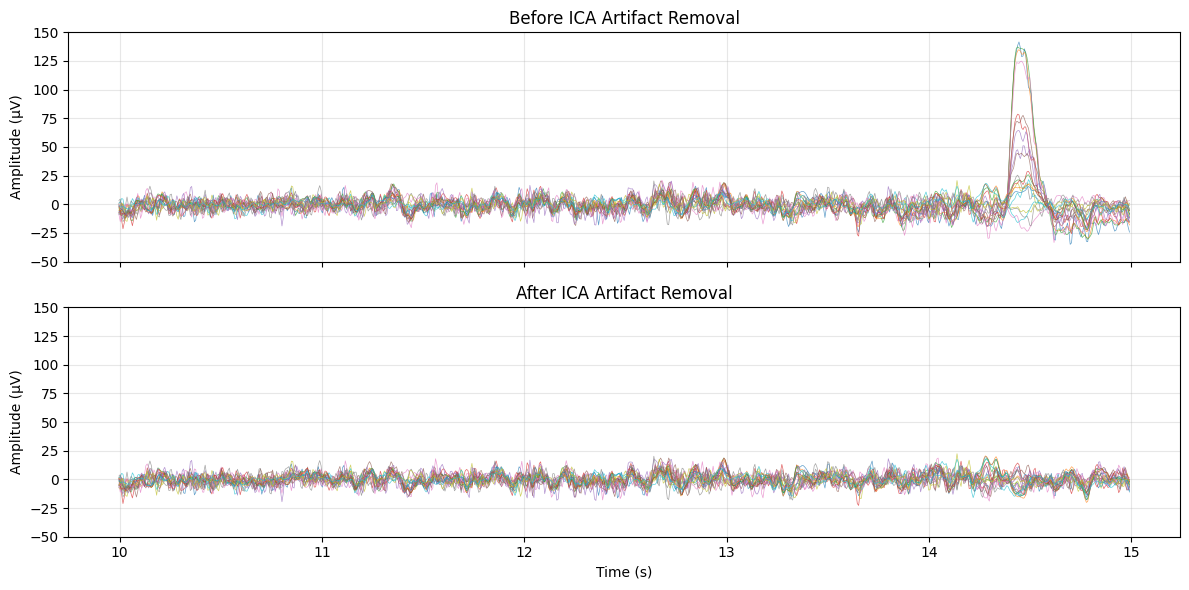

In [209]:
# 合并所有需要排除的成分
exclude_indices = list(set(eog_indices + ecg_indices))
ica.exclude = exclude_indices
print(f"将排除的成分索引: {exclude_indices}")

# 应用ICA去除伪迹成分
raw_clean = raw_ica.copy()
ica.apply(raw_clean, verbose=False)
print(f"\nICA伪迹去除完成")


# 对比去除前后的数据
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
start, end = int(10 * raw_ica.info['sfreq']), int(15 * raw_ica.info['sfreq'])
times = raw_ica.times[start:end]

# 去除前
data_before = raw_ica.get_data(picks='eeg')[:20, start:end]
axes[0].plot(times, data_before.T * 1e6, linewidth=0.5, alpha=0.7)
axes[0].set_ylim(-50, 150)
axes[0].set_ylabel('Amplitude (μV)')
axes[0].set_title('Before ICA Artifact Removal')
axes[0].grid(True, alpha=0.3)

# 去除后
data_after = raw_clean.get_data(picks='eeg')[:20, start:end]
axes[1].plot(times, data_after.T * 1e6, linewidth=0.5, alpha=0.7)
axes[1].set_ylim(-50, 150)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (μV)')
axes[1].set_title('After ICA Artifact Removal')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6. Epoch提取与基线校正

In [ ]:
# 查找事件
events = mne.find_events(raw, stim_channel='STI 014', verbose=False)

# 定义事件ID映射
event_dict = {
    'auditory/left': 1, 
    'auditory/right': 2,
    'visual/left': 3, 
    'visual/right': 4
}

# 创建epochs（自动进行基线校正）
epochs = mne.Epochs(
    raw_clean,           # 使用已清洗的数据
    picks='eeg',           # 仅选择EEG通道
    events, 
    event_id=event_dict,
    tmin=-0.2, 
    tmax=0.8,
    baseline=(-0.2, 0),  # 使用事件前200ms作为基线
    reject=dict(eeg=150e-6),  # 幅度超过±150μV的epochs将被拒绝
    preload=True, 
    verbose=False
)

print(f"Epochs创建完成:")
print(f"- 总试验数: {len(events)}")
print(f"- 保留试验数: {len(epochs)}")
print(f"- 拒绝试验数: {len(events) - len(epochs)}")
print(f"\n各条件试验数:")
for condition, count in epochs.event_id.items():
    actual_count = len(epochs[condition])
    print(f"  {condition}: {actual_count} trials")

Epochs创建完成:
- 总试验数: 319
- 保留试验数: 288
- 拒绝试验数: 31

各条件试验数:
  auditory/left: 72 trials
  auditory/right: 73 trials
  visual/left: 73 trials
  visual/right: 70 trials


### 7. 使用autoreject进行自动伪迹拒绝

正在学习最优拒绝参数...
最优插值通道数: {'eeg': 10}
最优共识比例: {'eeg': 0.5}
最优阈值: {'EEG 001': np.float64(6.12799040506772e-05), 'EEG 002': np.float64(3.8666669120631677e-05), 'EEG 003': np.float64(2.783848057986591e-05), 'EEG 004': np.float64(5.922079218934917e-05), 'EEG 005': np.float64(5.542629802523376e-05), 'EEG 006': np.float64(5.135480294674624e-05), 'EEG 007': np.float64(5.078475607179527e-05), 'EEG 008': np.float64(5.3061038376185976e-05), 'EEG 009': np.float64(4.171190091261704e-05), 'EEG 010': np.float64(3.91053658041257e-05), 'EEG 011': np.float64(4.582872209714938e-05), 'EEG 012': np.float64(5.158864672397008e-05), 'EEG 013': np.float64(5.292651785838985e-05), 'EEG 014': np.float64(5.853030996587089e-05), 'EEG 015': np.float64(6.686014882795386e-05), 'EEG 016': np.float64(3.729162347352268e-05), 'EEG 017': np.float64(4.0524934937478944e-05), 'EEG 018': np.float64(3.6238052651892436e-05), 'EEG 019': np.float64(3.558253406016586e-05), 'EEG 020': np.float64(3.085279971794083e-05), 'EEG 021': np.f

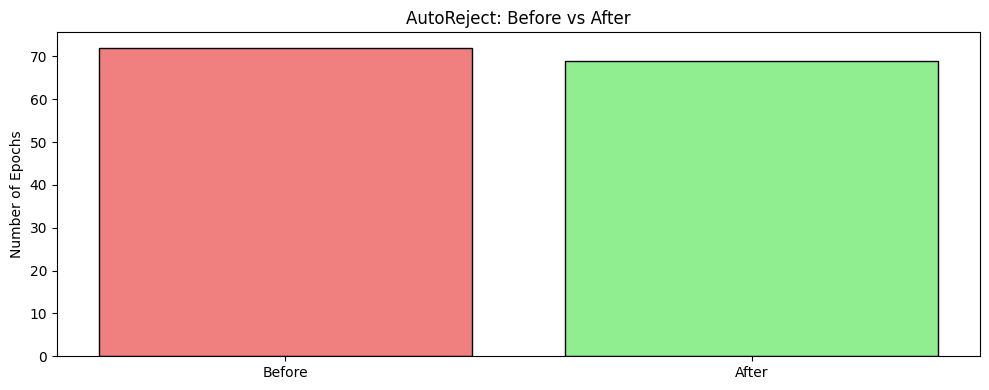

In [212]:
# 尝试导入autoreject（如果已安装）
try:
    from autoreject import AutoReject
    
    # 为演示目的，仅使用部分epochs
    epochs_subset = epochs['auditory/left'].copy()
    
    # 创建AutoReject实例，自动检测并修复 epochs 里的坏通道/坏试次。
    ar = AutoReject(
        n_interpolate=[5, 10], # 网格搜索的插值通道数范围，用于修复坏通道
        consensus=[0.5, 0.75], # 网格搜索的共识比例范围，用于判定坏epochs
        random_state=42,       # 随机种子，确保结果可重复
        verbose=False
    )
    
    print("正在学习最优拒绝参数...")
    ar.fit(epochs_subset)
    print(f"最优插值通道数: {ar.n_interpolate_}")
    print(f"最优共识比例: {ar.consensus_}")
    print(f"最优阈值: {ar.threshes_}")

    
    # 应用拒绝(拒绝和修复坏通道/坏试次)
    epochs_clean = ar.transform(epochs_subset)

    # epochs_clean = ar.fit_transform(epochs_subset)
    
    print(f"\nAutoReject结果:")
    print(f"- 原始epochs: {len(epochs_subset)}")
    print(f"- 清理后epochs: {len(epochs_clean)}")
    print(f"- 拒绝/修复: {len(epochs_subset) - len(epochs_clean)}")
    
    # 可视化拒绝日志
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(['Before', 'After'], [len(epochs_subset), len(epochs_clean)], 
           color=['lightcoral', 'lightgreen'], edgecolor='black')
    ax.set_ylabel('Number of Epochs')
    ax.set_title('AutoReject: Before vs After')
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("autoreject库未安装，跳过此步骤")
    print("安装方法: pip install autoreject")
    epochs_clean = epochs.copy()
    print("\n使用标准拒绝方法的结果作为替代")

### 8. 预处理流程总结

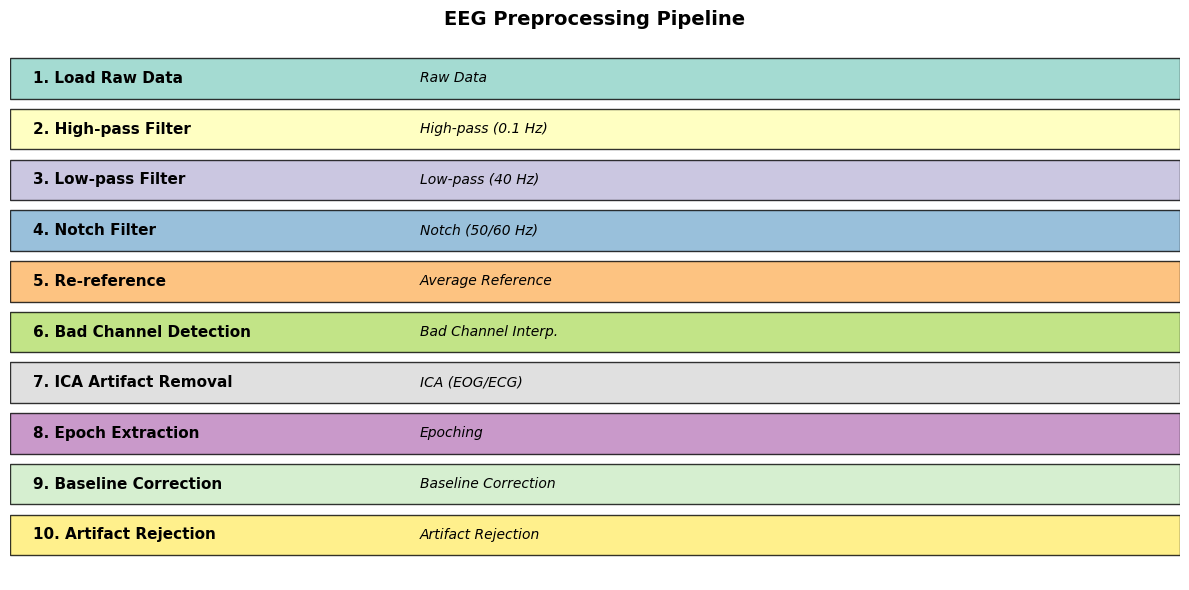


预处理后的epochs已保存到: d:\AI\trae_solo\ERP\outputs\preprocessed_epochs-epo.fif


In [ ]:
# 可视化完整的预处理流程
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

steps = [
    ("1. Load Raw Data", "Raw Data"),  # 加载原始数据
    ("2. High-pass Filter", "High-pass (0.1 Hz)"),  # 高通滤波
    ("3. Low-pass Filter", "Low-pass (40 Hz)"),  # 低通滤波
    ("4. Notch Filter", "Notch (50/60 Hz)"),  # 陷波滤波
    ("5. Re-reference", "Average Reference"),  # 重参考
    ("6. Bad Channel Detection", "Bad Channel Interp."),  # 坏道检测与插值
    ("7. ICA Artifact Removal", "ICA (EOG/ECG)"),  # ICA去伪迹
    ("8. Epoch Extraction", "Epoching"),  # Epoch提取
    ("9. Baseline Correction", "Baseline Correction"),  # 基线校正
    ("10. Artifact Rejection", "Artifact Rejection"),  # 伪迹拒绝
]

y_pos = np.arange(len(steps), 0, -1)
# 使用Set3颜色映射为每个步骤生成不同的颜色
colors = plt.cm.Set3(np.linspace(0, 1, len(steps)))

for i, (step, desc) in enumerate(steps):
    ax.barh(y_pos[i], 1, color=colors[i], edgecolor='black', alpha=0.8)
    ax.text(0.02, y_pos[i], f"{step}", va='center', fontsize=11, fontweight='bold')
    ax.text(0.35, y_pos[i], f"{desc}", va='center', fontsize=10, style='italic')

ax.set_xlim(0, 1)
ax.set_title('EEG Preprocessing Pipeline', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 创建目录
outputs_dir = os.path.abspath("../outputs")
os.makedirs(outputs_dir, exist_ok=True)
# 保存预处理后的数据
epochs_clean.save(os.path.join(outputs_dir, 'preprocessed_epochs-epo.fif'), overwrite=True)
print(f"\n预处理后的epochs已保存到: {os.path.join(outputs_dir, 'preprocessed_epochs-epo.fif')}")


## 单元小结

**关键知识点回顾：**
1. **滤波**：高通（去除低频漂移）、低通（去除高频噪声）、陷波（去除电源线干扰）
2. **重参考**：平均参考是最常用的方法，需要高密度电极
3. **坏道处理**：检测→标注→插值
4. **ICA去伪迹**：分解→识别（EOG/ECG）→排除→重建
5. **Epoch提取**：根据事件标记分段，设置合适的基线窗口
6. **伪迹拒绝**：手动阈值或自动学习（autoreject）

**预处理顺序建议：**
1. 滤波 → 2. 坏道检测 → 3. 重参考 → 4. ICA → 5. Epoch → 6. 基线校正 → 7. 伪迹拒绝

**下一步学习：**
- Unit 3将深入学习ERP分析，包括ERP组件识别、统计分析和可视化

**练习建议：**
1. 尝试不同的滤波参数，观察对数据的影响
2. 使用不同的ICA方法（fastica vs picard）比较结果
3. 调整伪迹拒绝的阈值，观察保留的epochs数量变化